In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/output/features.csv")

In [3]:
print(df.shape)
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

(1281576, 80)
label
0    640801
1    640775
Name: count, dtype: int64
label
0    0.50001
1    0.49999
Name: proportion, dtype: float64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281576 entries, 0 to 1281575
Data columns (total 80 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   label                         1281576 non-null  int64  
 1   original_url                  1281576 non-null  object 
 2   normalized_url                1281576 non-null  object 
 3   url_length                    1281576 non-null  int64  
 4   hostname_length               1281576 non-null  int64  
 5   domain_length                 1281576 non-null  int64  
 6   suffix_length                 1281576 non-null  int64  
 7   subdomain_length              1281576 non-null  int64  
 8   path_length                   1281576 non-null  int64  
 9   query_length                  1281576 non-null  int64  
 10  fragment_length               1281576 non-null  int64  
 11  path_depth                    1281576 non-null  int64  
 12  subdomain_count             

In [5]:
df.isna().sum().sort_values(ascending=False).head(20)

closest_brand            11
label                     0
normalized_url            0
original_url              0
hostname_length           0
domain_length             0
suffix_length             0
url_length                0
path_length               0
query_length              0
fragment_length           0
path_depth                0
subdomain_count           0
is_ip                     0
has_non_standard_port     0
subdomain_length          0
has_suspicious_tld        0
is_shortened              0
letter_count_url          0
digit_count_url           0
dtype: int64

In [6]:
df.head()

,label,original_url,normalized_url,url_length,hostname_length,domain_length,suffix_length,subdomain_length,path_length,query_length,...,sw_free,sw_bonus,sw_unlock,sw_webscr,sw_security,sw_billing,sw_support,sw_recover,sw_wallet,sw_authentication
0,1,@ ÒÊ \ t¹Ë¨öí ,http://@ ÒÊ \ t¹Ë¨öí ,25,16,15,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,H ÖË ] t¹[ÈöýE,http://H ÖË ] t¹[ÈöýE,23,4,16,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,l1,http://l1,10,3,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,http://Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,40,28,28,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
4,1,^oð]Â|¬|hõElòdy^Å~f b_jH0TRËR¯ÆÏa...,http://^oð]Â|¬|hõElòdy^Å~f b_jH0TRË...,93,23,23,0,0,5,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
columns_to_drop = ["original_url", "normalized_url", "closest_brand"]
df_model = df.drop(columns=columns_to_drop, errors="ignore")

In [8]:
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.fillna(0)

In [9]:
X = df_model.drop(columns=["label"])
y = df_model["label"]

print(X.shape)
print(y.shape)

(1281576, 76)
(1281576,)


In [10]:
X.select_dtypes(include=["object"]).columns.tolist()

[]

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/output/features.csv")
print(df.shape)
df.head()

(1281576, 80)


,label,original_url,normalized_url,url_length,hostname_length,domain_length,suffix_length,subdomain_length,path_length,query_length,...,sw_free,sw_bonus,sw_unlock,sw_webscr,sw_security,sw_billing,sw_support,sw_recover,sw_wallet,sw_authentication
0,1,@ ÒÊ \ t¹Ë¨öí ,http://@ ÒÊ \ t¹Ë¨öí ,25,16,15,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,H ÖË ] t¹[ÈöýE,http://H ÖË ] t¹[ÈöýE,23,4,16,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,l1,http://l1,10,3,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,http://Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,40,28,28,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
4,1,^oð]Â|¬|hõElòdy^Å~f b_jH0TRËR¯ÆÏa...,http://^oð]Â|¬|hõElòdy^Å~f b_jH0TRË...,93,23,23,0,0,5,0,...,0,0,0,0,0,0,0,0,0,0


Dataset shape: (1281576, 80)
Model dataset shape: (1281576, 77)
X shape: (1281576, 76)
y shape: (1281576,)

Label distribution:
label
0    640801
1    640775
Name: count, dtype: int64

Remaining object columns:
[]

Train/Test split:
X_train: (1025260, 76)
X_test : (256316, 76)
y_train: (1025260,)
y_test : (256316,)

LOGISTIC REGRESSION
Accuracy : 0.987936765555018
Precision: 0.9996883515394634
Recall   : 0.9761772853185595
F1-score : 0.9877929379066389

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    128161
           1       1.00      0.98      0.99    128155

    accuracy                           0.99    256316
   macro avg       0.99      0.99      0.99    256316
weighted avg       0.99      0.99      0.99    256316

Confusion Matrix:
[[128122     39]
 [  3053 125102]]

RANDOM FOREST
Accuracy : 0.9872267045365877
Precision: 0.9963039797791926
Recall   : 0.9780812297608364
F1-score : 0.9871085105880315

Cla

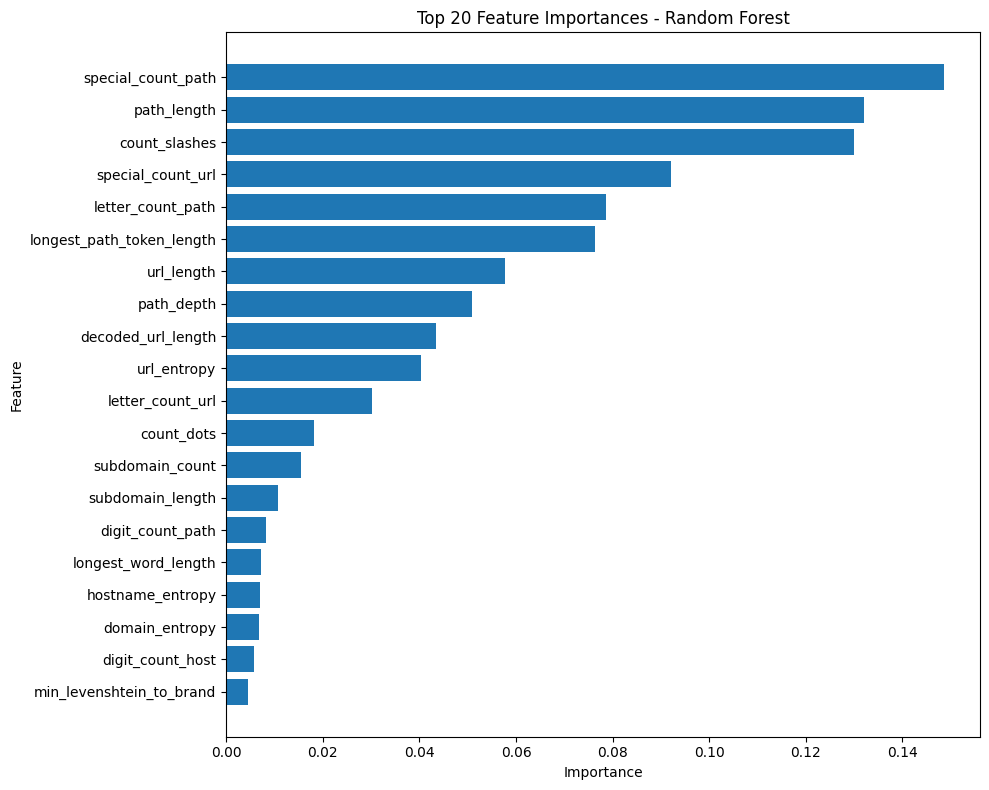

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 1. Preprocessing
columns_to_drop = ["original_url", "normalized_url", "closest_brand"]
df_model = df.drop(columns=columns_to_drop, errors="ignore")

df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.fillna(0)

X = df_model.drop(columns=["label"])
y = df_model["label"]

print("Dataset shape:", df.shape)
print("Model dataset shape:", df_model.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nLabel distribution:")
print(y.value_counts())
print("\nRemaining object columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# 3. Logistic Regression
print("\n" + "="*60)
print("LOGISTIC REGRESSION")
print("="*60)

lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# 4. Random Forest
print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# 5. Feature importance
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 20 Feature Importances:")
print(feature_importance.head(20))

# 6. Grafico feature importance
top_n = 20
top_features = feature_importance.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
et.fit(X_train, y_train)

y_pred_et = et.predict(X_test)

print("Extra Trees")
print("Accuracy :", accuracy_score(y_test, y_pred_et))
print("Precision:", precision_score(y_test, y_pred_et))
print("Recall   :", recall_score(y_test, y_pred_et))
print("F1-score :", f1_score(y_test, y_pred_et))
print()
print(classification_report(y_test, y_pred_et))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_et))

Extra Trees
Accuracy : 0.9868014482123628
Precision: 0.9951269841269841
Recall   : 0.978393351800554
F1-score : 0.986689225079184

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    128161
           1       1.00      0.98      0.99    128155

    accuracy                           0.99    256316
   macro avg       0.99      0.99      0.99    256316
weighted avg       0.99      0.99      0.99    256316

Confusion Matrix:
[[127547    614]
 [  2769 125386]]


In [14]:
results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": accuracy_score(y_test, y_pred_lr),
        "precision": precision_score(y_test, y_pred_lr),
        "recall": recall_score(y_test, y_pred_lr),
        "f1_score": f1_score(y_test, y_pred_lr),
    },
    {
        "model": "Random Forest",
        "accuracy": accuracy_score(y_test, y_pred_rf),
        "precision": precision_score(y_test, y_pred_rf),
        "recall": recall_score(y_test, y_pred_rf),
        "f1_score": f1_score(y_test, y_pred_rf),
    },
    {
        "model": "Extra Trees",
        "accuracy": accuracy_score(y_test, y_pred_et),
        "precision": precision_score(y_test, y_pred_et),
        "recall": recall_score(y_test, y_pred_et),
        "f1_score": f1_score(y_test, y_pred_et),
    }
])

results

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.987937,0.999688,0.976177,0.987793
1,Random Forest,0.987227,0.996304,0.978081,0.987109
2,Extra Trees,0.986801,0.995127,0.978393,0.986689


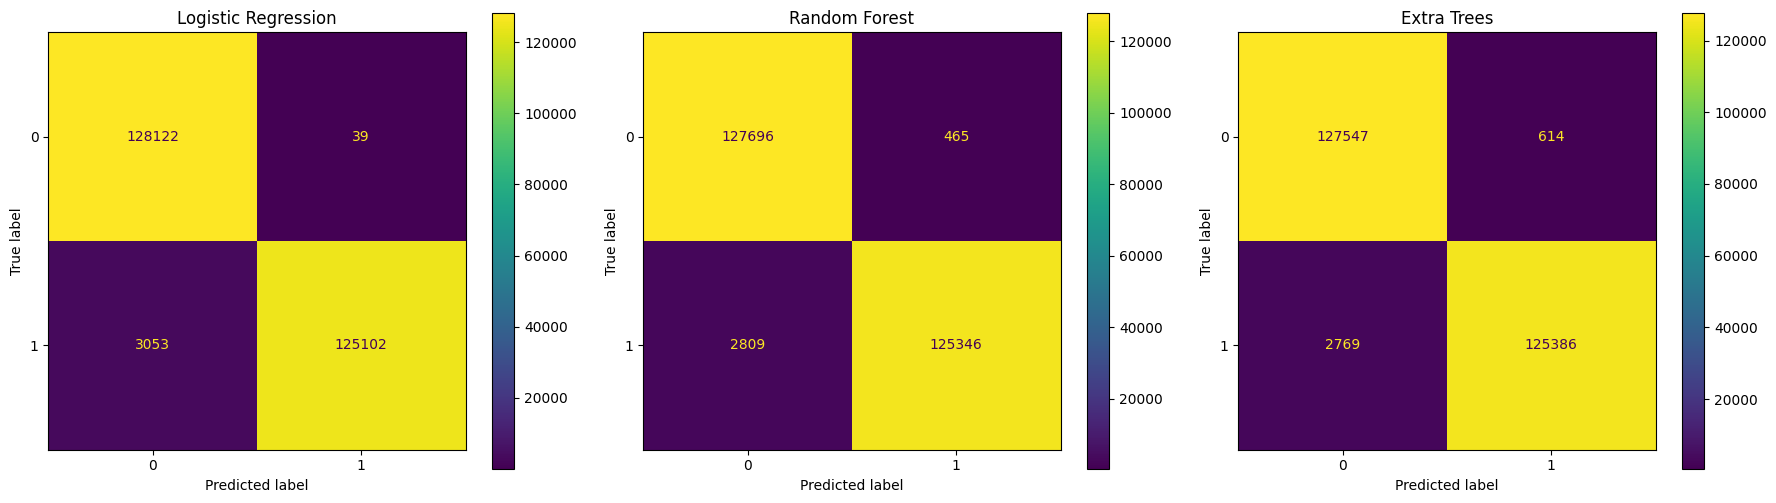

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0])
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1])
axes[1].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_et, ax=axes[2])
axes[2].set_title("Extra Trees")

plt.tight_layout()
plt.show()

In [16]:
results.to_csv("../data/output/model_results.csv", index=False)

In [17]:
feature_importance.to_csv("../data/output/feature_importance.csv", index=False)